In [26]:
from torch import nn, optim
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from torch.utils.data import Dataset, DataLoader

In [27]:
torch.manual_seed(1)

In [28]:
def Plot_2D_Plane(model, dataset, n=0):
    w1 = model.state_dict()['linear.weight'].numpy()[0][0]
    w2 = model.state_dict()['linear.weight'].numpy()[0][1]
    b = model.state_dict()['linear.bias'].numpy()

    # Data
    x1 = dataset.x[:, 0].view(-1, 1).numpy()
    x2 = dataset.x[:, 1].view(-1, 1).numpy()
    y = dataset.y.numpy()

    # Make plane
    X, Y = np.meshgrid(np.arange(x1.min(), x1.max(), 0.05), np.arange(x2.min(), x2.max(), 0.05))
    yhat = w1 * X + w2 * Y + b

    # Plotting
    fig = plt.figure()
    ax = fig.gca(projection='3d')

    ax.plot(x1[:, 0], x2[:, 0], y[:, 0],'ro', label='y') # Scatter plot

    ax.plot_surface(X, Y, yhat) # Plane plot

    ax.set_xlabel('x1 ')
    ax.set_ylabel('x2 ')
    ax.set_zlabel('y')
    plt.title('estimated plane iteration:' + str(n))
    ax.legend()

    plt.show()

In [29]:
class Dataset(Dataset):
    def __init__(self):
        self.x = torch.zeros(20, 2)
        self.x[:, 0] = torch.arange(-1, 1, 0.1)
        self.x[:, 1] = torch.arange(-1, 1, 0.1)
        self.w = torch.tensor([[1.0], [1.0]])
        self.b = 1
        self.f = torch.mm(self.x, self.w) + self.b
        self.y = self.f + 0.1 * torch.randn((self.x.shape[0], 1))
        self.len = self.x.shape[0]

    def __getitem__(self, index):
        return self.x[index], self.y[index]

    def __len__(self):
        return self.len

In [30]:
data_set = Dataset()

In [31]:
class linear_regression(nn.Module):
    def __init__(self, input_size, output_size):
        super(linear_regression, self).__init__()
        self.linear = nn.Linear(input_size, output_size)

    def forward(self, x):
        yhat = self.linear(x)
        return yhat

In [32]:
model = linear_regression(2, 1)
print(list(model.parameters()))

[Parameter containing:
tensor([[ 0.6209, -0.1178]], requires_grad=True), Parameter containing:
tensor([0.3026], requires_grad=True)]


In [33]:
optimizer = optim.SGD(model.parameters(), lr=0.1)
criterion = nn.MSELoss()
train_loader = DataLoader(dataset=data_set, batch_size=2)

In [34]:
LOSS = []
epochs = 100

def train_model(epochs):
    for epoch in range(epochs):
        for x, y in train_loader:
            yhat = model(x)
            loss = criterion(yhat, y)
            print(loss.item())
            LOSS.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
train_model(epochs)

0.7158632278442383
0.01704590395092964
0.10395438969135284
0.18733824789524078
0.41408830881118774
0.5873252153396606
0.5742130279541016
0.6638832688331604
0.6784318089485168
0.6617147922515869
0.6895422339439392
0.09786363691091537
0.0009930470259860158
0.0066905515268445015
0.013248290866613388
0.021799204871058464
0.0010125430999323726
0.0026166322641074657
0.010046405717730522
0.04549853131175041
0.05993153154850006
0.014211764559149742
0.010120014660060406
0.005261137615889311
0.0067716604098677635
0.012129101902246475
0.006381751969456673
0.007114417850971222
0.004348319489508867
0.015359179116785526
0.011763335205614567
0.006024383474141359
0.014840472489595413
0.005261510610580444
0.006688987836241722
0.01177823357284069
0.008170383051037788
0.00945313274860382
0.005509413778781891
0.012508876621723175
0.0072881318628787994
0.0050916424952447414
0.015834536403417587
0.005297127645462751
0.006747649051249027
0.011770876124501228
0.008399222046136856
0.00978335551917553
0.0057023

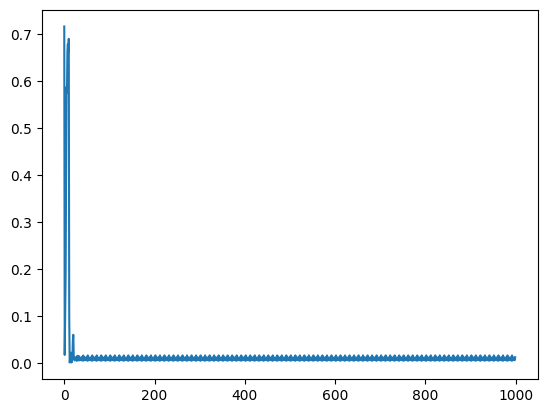

In [35]:
plt.plot(LOSS)